<a href="https://colab.research.google.com/github/Rakib007Nabila/Detection-of-Parkinsons-Using-ML/blob/main/EECA_Unmodified_09_09_25.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd

# Parameters for the network
GRID_SIZE = 100  # Size of the area (100x100 meters)
NUM_NODES = 2000  # Total number of nodes
INITIAL_ENERGY = 5.0  # Initial energy of each node in Joules
COMMUNICATION_RANGE = 20  # Communication range in meters
EVENT_RANGE = 10  # Maximum distance to detect an event

# Initialize the random seed for reproducibility

np.random.seed(32)

# Generate node properties
node_ids = np.arange(NUM_NODES)
x_positions = np.random.uniform(0, GRID_SIZE, NUM_NODES)  # Random x-coordinates
y_positions = np.random.uniform(0, GRID_SIZE, NUM_NODES)  # Random y-coordinates
energies = np.random.uniform(0, INITIAL_ENERGY, NUM_NODES)  # Random energy
event_counts = np.random.randint(0, 10, NUM_NODES)  # Random event counts

# Base station position (center of the grid)
base_station = (GRID_SIZE / 2, GRID_SIZE / 2)

# Function to calculate distance
def calculate_distance(x1, y1, x2, y2):
    return np.sqrt((x1 - x2) ** 2 + (y1 - y2) ** 2)

# Calculate distances to base station
distances_to_bs = calculate_distance(x_positions, y_positions, base_station[0], base_station[1])

# Calculate neighbors within communication range
neighbors = []
for i in range(NUM_NODES):
    dist_to_others = calculate_distance(
        x_positions[i], y_positions[i], x_positions, y_positions
    )
    neighbors.append(np.sum(dist_to_others <= COMMUNICATION_RANGE) - 1)  # Exclude self

# Create the dataset
data = {
    "Node_ID": node_ids,
    "X_Position": x_positions,
    "Y_Position": y_positions,
    "Residual_Energy": energies,
    "Event_Count": event_counts,
    "Distance_to_BS": distances_to_bs,
    "Number_of_Neighbors": neighbors,
}

dataset2 = pd.DataFrame(data)

# Save the dataset to a CSV file
dataset2.to_csv("wsn_dataset2.csv", index=False)

print("Dataset created and saved as 'wsn_dataset2.csv'.")
print(dataset2)



Dataset created and saved as 'wsn_dataset2.csv'.
      Node_ID  X_Position  Y_Position  Residual_Energy  Event_Count  \
0           0   85.888927   13.716697         2.601208            3   
1           1   37.271115   25.205217         0.433371            6   
2           2   55.512878   29.990840         2.239524            3   
3           3   95.565655   33.260331         1.114435            3   
4           4   73.666960   56.858685         2.839110            5   
...       ...         ...         ...              ...          ...   
1995     1995   83.833247   60.958611         1.965986            2   
1996     1996    2.000106   27.563499         2.399849            0   
1997     1997   38.788223   10.381297         3.408828            1   
1998     1998   68.571528   88.511785         0.971310            8   
1999     1999   62.922706   44.846162         3.604689            4   

      Distance_to_BS  Number_of_Neighbors  
0          51.034235                  195  
1         

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


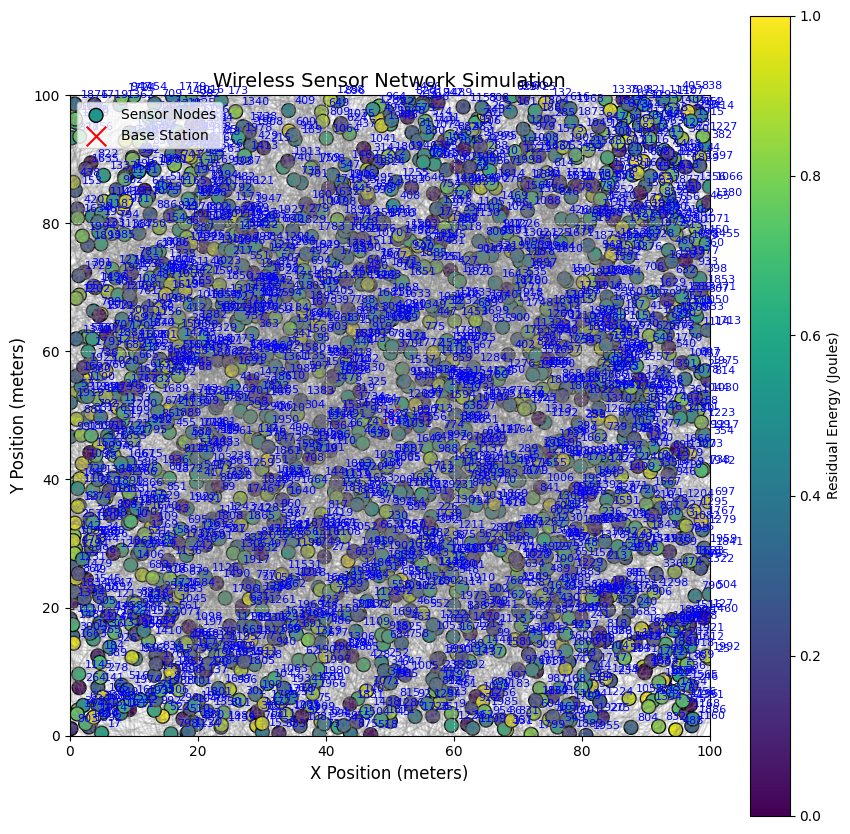

In [ ]:
import matplotlib.pyplot as plt

# Load the dataset
dataset2 = pd.read_csv("wsn_dataset2.csv")


# Extract node properties
x_positions = dataset2["X_Position"]
y_positions = dataset2["Y_Position"]
residual_energy = dataset2["Residual_Energy"]
base_station = (GRID_SIZE / 2, GRID_SIZE / 2)  # Center of the grid

# Plot the sensor network
plt.figure(figsize=(10, 10))
plt.scatter(x_positions, y_positions, c=residual_energy, cmap="viridis", s=100, edgecolors="black", label="Sensor Nodes")
plt.scatter(base_station[0], base_station[1], c="red", s=200, label="Base Station", marker="x")

# Annotate node IDs
for i, (x, y) in enumerate(zip(x_positions, y_positions)):
    plt.text(x + 1, y + 1, str(i), fontsize=8, color="blue")

# Draw communication range circles for each node (optional)
for i in range(NUM_NODES):
    circle = plt.Circle((x_positions[i], y_positions[i]), COMMUNICATION_RANGE, color="gray", fill=False, alpha=0.2)
    plt.gca().add_patch(circle)

# Plot settings
plt.title("Wireless Sensor Network Simulation", fontsize=14)
plt.xlabel("X Position (meters)", fontsize=12)
plt.ylabel("Y Position (meters)", fontsize=12)
plt.colorbar(label="Residual Energy (Joules)")
plt.grid(color="lightgray", linestyle="--", linewidth=0.5)
plt.legend()
plt.xlim(0, GRID_SIZE)
plt.ylim(0, GRID_SIZE)
plt.gca().set_aspect('equal', adjustable='box')

# Show plot
plt.subplots_adjust(left=0.1, right=0.9, top=0.9, bottom=0.1)
plt.show()


In [ ]:
import numpy as np
import pandas as pd

# Parameters for the network
GRID_SIZE = 100  # Size of the area (100x100 meters)
NUM_NODES = 100  # Total number of nodes
INITIAL_ENERGY = 5.0  # Initial energy of each node in Joules
THRESHOLD_ENERGY = 1.0  # Minimum energy to participate in CH selection
COMMUNICATION_RANGE = 20  # Communication range in meters
EVENT_RANGE = 10  # Maximum distance to detect an event

# Initialize the random seed for reproducibility
np.random.seed(42)

# Generate node properties
node_ids = np.arange(NUM_NODES)
x_positions = np.random.uniform(0, GRID_SIZE, NUM_NODES)  # Random x-coordinates
y_positions = np.random.uniform(0, GRID_SIZE, NUM_NODES)  # Random y-coordinates
energies = np.full(NUM_NODES, INITIAL_ENERGY)
event_counts = np.random.randint(0, 10, NUM_NODES)  # Random event counts

# Base station position (center of the grid)
base_station = (GRID_SIZE / 2, GRID_SIZE / 2)

# Function to calculate distance
def calculate_distance(x1, y1, x2, y2):
    return np.sqrt((x1 - x2) ** 2 + (y1 - y2) ** 2)

# Calculate distances to base station
distances_to_bs = calculate_distance(x_positions, y_positions, base_station[0], base_station[1])

# Calculate neighbors within communication range
neighbors = []
for i in range(NUM_NODES):
    dist_to_others = calculate_distance(
        x_positions[i], y_positions[i], x_positions, y_positions
    )
    neighbors.append(np.sum(dist_to_others <= COMMUNICATION_RANGE) - 1)  # Exclude self

# Create the dataset
data = {
    "Node_ID": node_ids,
    "X_Position": x_positions,
    "Y_Position": y_positions,
    "Residual_Energy": energies,
    "Event_Count": event_counts,
    "Distance_to_BS": distances_to_bs,
    "Number_of_Neighbors": neighbors,
}

dataset1 = pd.DataFrame(data)

# Save the dataset to a CSV file
dataset1.to_csv("wsn_dataset1.csv", index=False)

print("Dataset created and saved as 'wsn_dataset1.csv'.")
print(dataset1)



Dataset created and saved as 'wsn_dataset1.csv'.
    Node_ID  X_Position  Y_Position  Residual_Energy  Event_Count  \
0         0   37.454012    3.142919              5.0            7   
1         1   95.071431   63.641041              5.0            3   
2         2   73.199394   31.435598              5.0            0   
3         3   59.865848   50.857069              5.0            7   
4         4   15.601864   90.756647              5.0            3   
..      ...         ...         ...              ...          ...   
95       95   49.379560   34.920957              5.0            3   
96       96   52.273283   72.595568              5.0            3   
97       97   42.754102   89.711026              5.0            0   
98       98    2.541913   88.708642              5.0            7   
99       99   10.789143   77.987555              5.0            2   

    Distance_to_BS  Number_of_Neighbors  
0        48.507607                    4  
1        47.090465                    

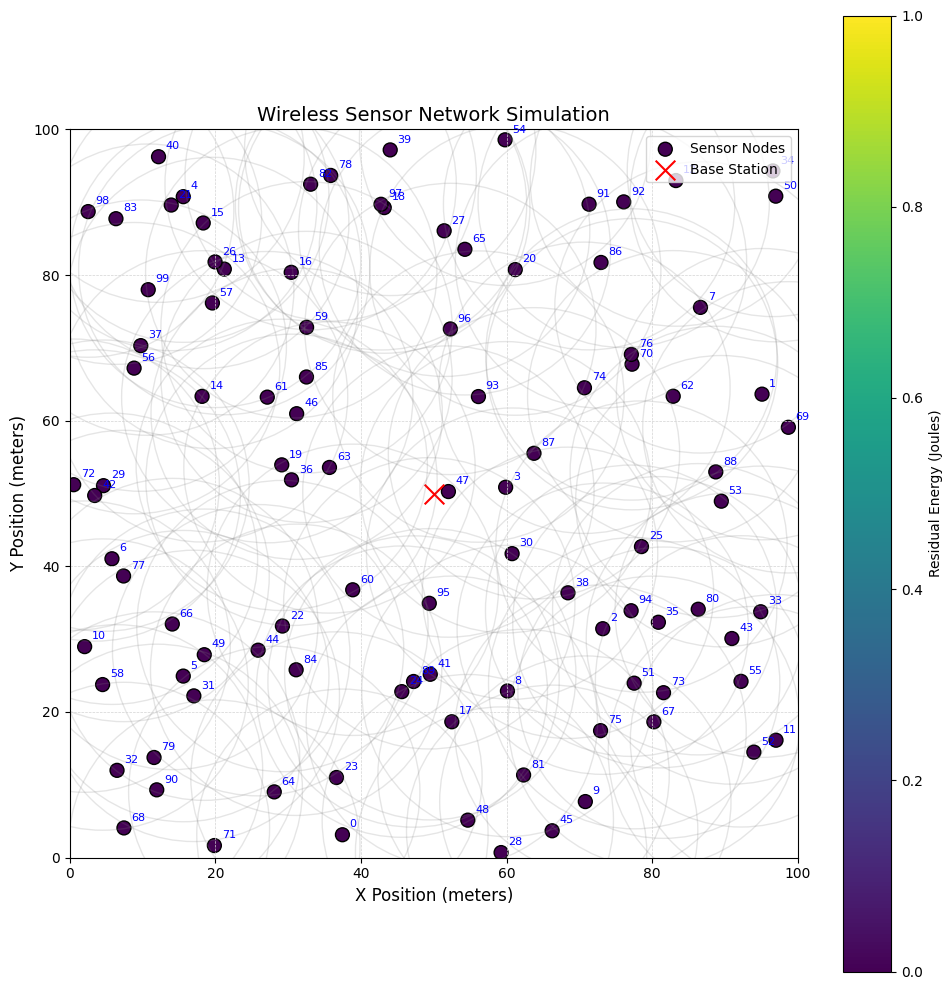

In [ ]:
import matplotlib.pyplot as plt

# Load the dataset
dataset1 = pd.read_csv("wsn_dataset1.csv")


# Extract node properties
x_positions = dataset1["X_Position"]
y_positions = dataset1["Y_Position"]
residual_energy = dataset1["Residual_Energy"]
base_station = (GRID_SIZE / 2, GRID_SIZE / 2)  # Center of the grid

# Plot the sensor network
plt.figure(figsize=(10, 10))
plt.scatter(x_positions, y_positions, c=residual_energy, cmap="viridis", s=100, edgecolors="black", label="Sensor Nodes")
plt.scatter(base_station[0], base_station[1], c="red", s=200, label="Base Station", marker="x")

# Annotate node IDs
for i, (x, y) in enumerate(zip(x_positions, y_positions)):
    plt.text(x + 1, y + 1, str(i), fontsize=8, color="blue")

# Draw communication range circles for each node (optional)
for i in range(NUM_NODES):
    circle = plt.Circle((x_positions[i], y_positions[i]), COMMUNICATION_RANGE, color="gray", fill=False, alpha=0.2)
    plt.gca().add_patch(circle)

# Plot settings
plt.title("Wireless Sensor Network Simulation", fontsize=14)
plt.xlabel("X Position (meters)", fontsize=12)
plt.ylabel("Y Position (meters)", fontsize=12)
plt.colorbar(label="Residual Energy (Joules)")
plt.grid(color="lightgray", linestyle="--", linewidth=0.5)
plt.legend()
plt.xlim(0, GRID_SIZE)
plt.ylim(0, GRID_SIZE)
plt.gca().set_aspect('equal', adjustable='box')

# Show plot
plt.tight_layout()
plt.show()


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import numpy as np
import pandas as pd

# Load datasets
dataset2 = pd.read_csv("wsn_dataset2.csv")  # Training dataset
dataset1 = pd.read_csv("wsn_dataset1.csv")  # Testing dataset

# Define input features and target output
alpha = 0.6  # Weight for Residual Energy and Neighbors
beta = 0.5   # Weight for Distance and Event Count

# Calculate Target Output for Training Dataset
dataset2["Target_Score"] = (
    (alpha * dataset2["Residual_Energy"] +
     (1 - alpha) * dataset2["Number_of_Neighbors"]) /
    (beta * dataset2["Distance_to_BS"] +
     (1 - beta) * dataset2["Event_Count"])
)

# Define input features (X) and target (y) for training
X = dataset2[["Residual_Energy", "Event_Count", "Distance_to_BS", "Number_of_Neighbors"]]
y = dataset2["Target_Score"]

# Normalize input features using MinMaxScaler
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Split training data into training and validation sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

# Build the ANN model
model = Sequential([
    Dense(8, activation="relu", input_shape=(X_train.shape[1],)),  # Hidden layer with 8 neurons
    Dense(8, activation="relu"),                                   # Another hidden layer with 8 neurons
    Dense(1, activation="linear")                                  # Output layer for score prediction
])

# Compile the model
model.compile(optimizer="adam", loss="mse", metrics=["mae"])

# Train the model
history = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=100, batch_size=8, verbose=1)

# Prepare Testing Dataset (dataset1) for Prediction
X1 = dataset1[["Residual_Energy", "Event_Count", "Distance_to_BS", "Number_of_Neighbors"]]
X1_scaled = scaler.transform(X1)  # Use same scaler for consistency

# Predict scores for all nodes in the test dataset
dataset1["Predicted_Score"] = model.predict(X1_scaled).flatten()

# Define grid size and region size
GRID_SIZE = 100
NUM_REGIONS_X = 4
NUM_REGIONS_Y = 3
region_width = GRID_SIZE / NUM_REGIONS_X
region_height = GRID_SIZE / NUM_REGIONS_Y

# Function to assign nodes to regions
def assign_region(x, y, width, height):
    return (int(x // width), int(y // height))

# Assign nodes to regions in dataset1
dataset1["Region"] = dataset1.apply(
    lambda row: assign_region(row["X_Position"], row["Y_Position"], region_width, region_height), axis=1
)

# Filter nodes with Residual Energy >= 1J for CH selection
eligible_nodes = dataset1[dataset1["Residual_Energy"] >= THRESHOLD_ENERGY].copy()

# Re-assign regions to eligible nodes (optional if same as above)
eligible_nodes["Region"] = eligible_nodes.apply(
    lambda row: assign_region(row["X_Position"], row["Y_Position"], region_width, region_height), axis=1
)

# Select the highest-scoring node in each region as the Cluster Head (CH)
cluster_heads = eligible_nodes.loc[eligible_nodes.groupby("Region")["Predicted_Score"].idxmax()]

# Mark CHs in original dataset
dataset1["Is_CH"] = dataset1["Node_ID"].isin(cluster_heads["Node_ID"])

# Output Cluster Heads
print("Cluster Heads Selected (Only nodes with ≥ 1J energy):")
print(cluster_heads[["Node_ID", "Region", "Predicted_Score"]])

# Save the updated dataset with CH info
dataset1.to_csv("wsn_with_ch.csv", index=False)
print("\nDataset with Cluster Heads saved as 'wsn_with_ch.csv'.")


Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


175/175 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 31.0544 - mae: 4.1878 - val_loss: 24.9699 - val_mae: 2.5892
Epoch 2/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 20.4298 - mae: 2.4996 - val_loss: 19.3939 - val_mae: 2.4344
Epoch 3/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 20.3417 - mae: 2.3962 - val_loss: 16.6158 - val_mae: 2.1290
Epoch 4/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 20.1056 - mae: 2.1572 - val_loss: 14.1211 - val_mae: 1.7395
Epoch 5/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 7.1099 - mae: 1.4621 - val_loss: 11.9797 - val_mae: 1.6293
Epoch 6/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 10.6752 - mae: 1.5474 - val_loss: 10.3260 - val_mae: 1.1449
Epoch 7/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 4.6066 - mae: 0.9570 - val_loss: 9.1289 - val_mae: 1.1538
Epoch 8/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 13.3640 - mae: 1.2318 - val_loss: 8.1761 - val_mae: 1.0354
Epoch 9/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/

In [ ]:
# Create an array to store all Cluster Head Node_IDs
cluster_heads_array = cluster_heads["Node_ID"].tolist()

# Output the array for inspection
print("\nCluster Heads stored in array:")
print(cluster_heads_array)



Cluster Heads stored in array:
[5, 6, 98, 41, 63, 59, 2, 47, 96, 11, 1, 7]


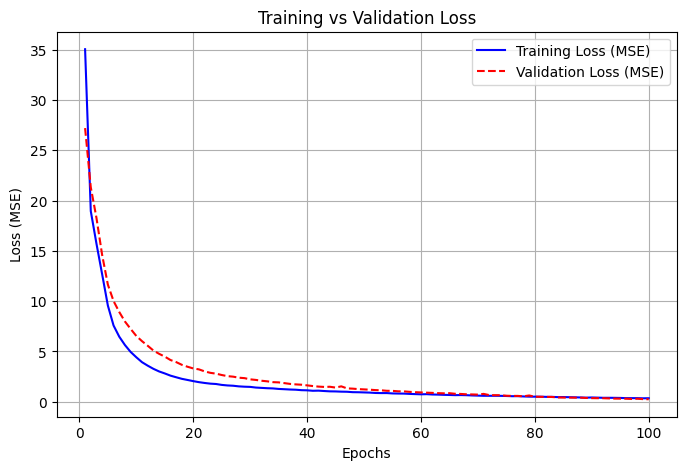

In [ ]:
import matplotlib.pyplot as plt

# Extract loss values from training history
train_loss = history.history["loss"]
val_loss = history.history["val_loss"]

# Plot Loss (MSE) Over Epochs
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(train_loss) + 1), train_loss, label="Training Loss (MSE)", color="blue")
plt.plot(range(1, len(val_loss) + 1), val_loss, label="Validation Loss (MSE)", color="red", linestyle="dashed")

plt.xlabel("Epochs")
plt.ylabel("Loss (MSE)")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()


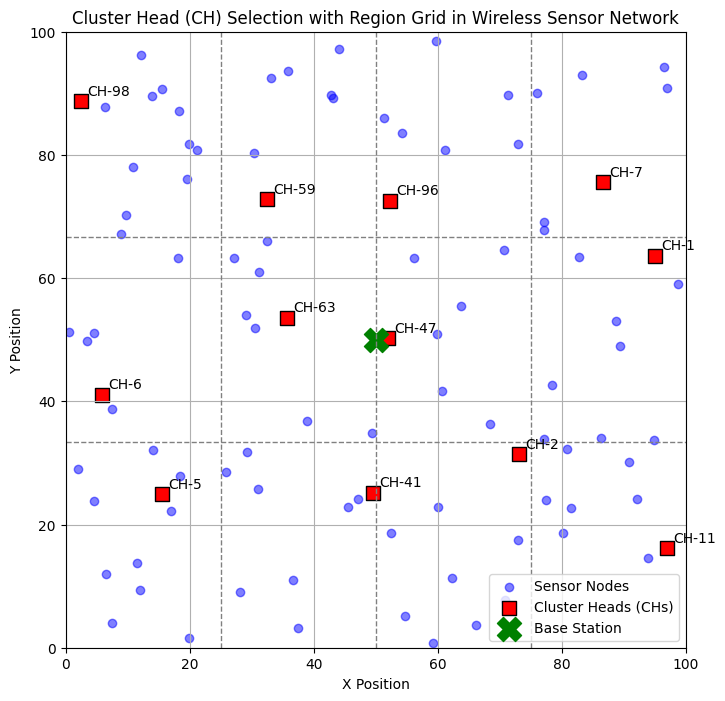

In [ ]:
import matplotlib.pyplot as plt

# Define the number of regions (should match your CH selection logic)
NUM_REGIONS_X = 4
NUM_REGIONS_Y = 3
region_width = GRID_SIZE / NUM_REGIONS_X
region_height = GRID_SIZE / NUM_REGIONS_Y

# Plot all sensor nodes
plt.figure(figsize=(8, 8))
plt.scatter(dataset1["X_Position"], dataset1["Y_Position"], c='blue', label="Sensor Nodes", alpha=0.5)

# Plot Cluster Heads (CHs) in red
plt.scatter(cluster_heads["X_Position"], cluster_heads["Y_Position"], c='red', label="Cluster Heads (CHs)",
            marker="s", edgecolors='black', s=100)

# Mark Base Station (center of the grid)
base_station = (GRID_SIZE / 2, GRID_SIZE / 2)
plt.scatter(base_station[0], base_station[1], c="green", s=300, marker="X", label="Base Station")

# Annotate each CH with its Node_ID
for _, row in cluster_heads.iterrows():
    plt.text(row["X_Position"] + 1, row["Y_Position"] + 1, f"CH-{int(row['Node_ID'])}", fontsize=10, color='black')

# Draw vertical grid lines (region boundaries)
for i in range(1, NUM_REGIONS_X):
    plt.axvline(x=i * region_width, color='gray', linestyle='--', linewidth=1)

# Draw horizontal grid lines (region boundaries)
for j in range(1, NUM_REGIONS_Y):
    plt.axhline(y=j * region_height, color='gray', linestyle='--', linewidth=1)

# Add axis labels and title
plt.xlabel("X Position")
plt.ylabel("Y Position")
plt.title("Cluster Head (CH) Selection with Region Grid in Wireless Sensor Network")
plt.legend()
plt.grid(True)
plt.xlim(0, GRID_SIZE)
plt.ylim(0, GRID_SIZE)

# Show the plot
plt.show()


In [ ]:
# ==============================
# Parameters
# ==============================
GRID_SIZE = 100
NUM_NODES = 100
INITIAL_ENERGY = 5.0
P = 0.1               # desired CH probability
M_SESSIONS = 15       # TDMA sessions per round
TE = 0.1              # threshold energy
PT = 10               # proximity threshold
MCS = 12              # max cluster size

# Radio model
E_ELEC = 50e-9
E_DA   = 5e-9
E_AMP  = 100e-12

# Packet sizes
K_DATA = 100 * 8
K_CTRL = 20 * 8

# Node positions
SEED = 42
np.random.seed(SEED)
x_positions = np.random.uniform(0, GRID_SIZE, NUM_NODES)
y_positions = np.random.uniform(0, GRID_SIZE, NUM_NODES)
base_station = (GRID_SIZE/2, GRID_SIZE/2)



# ==============================
# Energy functions
# ==============================
def energy_tx(k_bits, distance):
    return (E_ELEC * k_bits) + (E_AMP * k_bits * (distance ** 2))

def energy_rx(k_bits):
    return E_ELEC * k_bits

def energy_da(k_bits):
    return E_DA * k_bits

def calculate_distance(x1, y1, x2, y2):
    return np.sqrt((x1 - x2)**2 + (y1 - y2)**2)

def broadcast_radius_for_ch(ch, members):
    """Compute conservative radius to reach members"""
    if len(members) == 0:
        return calculate_distance(x_positions[ch], y_positions[ch], base_station[0], base_station[1])

    return max(calculate_distance(x_positions[ch], y_positions[ch],
                                  x_positions[m], y_positions[m]) for m in members)



NameError: name 'np' is not defined

In [ ]:
# ==============================
# EECA Simulation
# ==============================
def run_eeca():
    node_energy = {i: INITIAL_ENERGY for i in range(NUM_NODES)}
    death_round = {i: None for i in range(NUM_NODES)}

    alive_node_count_per_round = []
    total_energy_per_round = []

    round_num = 0
    while any(e > 0 for e in node_energy.values()):
        round_num += 1
        alive_nodes = [i for i, e in node_energy.items() if e > 0]
        if round_num % 100 == 0:
            print(f"Round {round_num}: {len(alive_nodes)} alive")

        alive_node_count_per_round.append(len(alive_nodes))
        total_energy_per_round.append(sum(node_energy.values()))

        # --- CH selection ---
        # --- Use pre-selected CHs from the ANN ---
        final_chs = []

        # Add all cluster heads from the stored array to final_chs
        for ch in cluster_heads_array:
          if ch in alive_nodes:  # Ensure that the node is still alive
            final_chs.append(ch)

# If no CHs are selected (rare), pick the node with the max energy
        if len(final_chs) == 0:
          max_energy_node = max(alive_nodes, key=lambda n: node_energy[n])
          final_chs = [max_energy_node]


# If no final CHs (rare), pick max alive node
        if len(final_chs) == 0:
            max_energy_node = max(alive_nodes, key=lambda n: node_energy[n])
            final_chs = [max_energy_node]



        # CHs broadcast an ADV (control) packet; non-CH nodes receive ADVs.
        # -----------------------------
        # For each CH: broadcast distance set conservatively to farthest alive node (or BS fallback)
        for ch in final_chs:
            # compute conservative broadcast radius to reach all alive nodes except self
            other_nodes = [n for n in alive_nodes if n != ch]
            if other_nodes:
                d_adv = max(calculate_distance(x_positions[ch], y_positions[ch],
                                               x_positions[n], y_positions[n]) for n in other_nodes)
            else:
                d_adv = calculate_distance(x_positions[ch], y_positions[ch], base_station[0], base_station[1])

            node_energy[ch] -= energy_tx(K_CTRL, d_adv)   # <-- ADV transmit energy
            if node_energy[ch] <= 0 and death_round[ch] is None:
                death_round[ch] = round_num

        # For each non-CH alive node: receive p ADV packets (p = number of final_chs)
        p_adv = len(final_chs)
        for n in alive_nodes:
            if n in final_chs:
                continue
            node_energy[n] -= p_adv * energy_rx(K_CTRL)   # <-- ADV receive energy (p ADVs)
            if node_energy[n] <= 0 and death_round[n] is None:
                death_round[n] = round_num


        assigned = {ch: [] for ch in final_chs}
        attempt_index = {n: 0 for n in alive_nodes if n not in final_chs}
        node_assigned_flag = {n: False for n in alive_nodes if n not in final_chs}

        # --- Join Requests + ACK loop ---
        max_attempts = len(final_chs)
        for attempt in range(max_attempts):
            join_requests = {ch: [] for ch in final_chs}
            for node in alive_nodes:
                if node in final_chs or node_assigned_flag[node]:
                    continue
                dists = [(ch, calculate_distance(x_positions[node], y_positions[node],
                                                 x_positions[ch], y_positions[ch]))
                         for ch in final_chs]
                dists.sort(key=lambda x: x[1])
                if attempt_index[node] < len(dists):
                    chosen_ch, d = dists[attempt_index[node]]
                    join_requests[chosen_ch].append((node, d))
                    node_energy[node] -= energy_tx(K_CTRL, d)
                    if node_energy[node] <= 0 and death_round[node] is None:
                        death_round[node] = round_num

            for ch in final_chs:
                num_requests = len(join_requests[ch])
                node_energy[ch] -= num_requests * energy_rx(K_CTRL)
                if node_energy[ch] <= 0 and death_round[ch] is None:
                    death_round[ch] = round_num

                if num_requests == 0:
                    continue
                current_size = len(assigned[ch])
                join_requests[ch].sort(key=lambda x: x[1])
                slots_left = max(0, MCS - current_size)
                newly_accepted = [n for n, _d in join_requests[ch][:slots_left]]
                assigned[ch].extend(newly_accepted)

                # ACK for all requesters (accepted + rejected)
                all_requesters = [n for n, _d in join_requests[ch]]
                d_bcast = broadcast_radius_for_ch(ch, all_requesters)
                node_energy[ch] -= energy_tx(K_CTRL, d_bcast)

                for n in all_requesters:
                  if node_energy[n] > 0:
                    node_energy[n] -= energy_rx(K_CTRL)
                    if node_energy[n] <= 0 and death_round[n] is None:
                      death_round[n] = round_num



                    for n in newly_accepted:
                      if node_energy[n] > 0:
                        node_assigned_flag[n] = True
                      else:
                        # node died while receiving ACK — it remains in 'assigned' list but is dead
                        pass

                # --- handle rejected nodes explicitly ---
                rejected = [n for n, _d in join_requests[ch] if n not in newly_accepted]
                for n in rejected:
                  attempt_index[n] += 1



        # --- TDMA broadcast ---
        for ch in final_chs:
            d_bcast = broadcast_radius_for_ch(ch, assigned[ch])
            node_energy[ch] -= energy_tx(K_CTRL, d_bcast)
            for n in assigned[ch]:
                node_energy[n] -= energy_rx(K_CTRL)
                if node_energy[n] <= 0 and death_round[n] is None:
                    death_round[n] = round_num

        # probability of having data in this session (applies per member)
        P_DATA_SESSION = np.random.random()
        # --- Steady-state data phase ---
        for session in range(M_SESSIONS):

            for ch in final_chs:
                recv_nodes = []
                for n in assigned[ch]:
                    if node_energy[n] <= 0:
                        continue
                    # decide if node has data this session
                    if np.random.random() < P_DATA_SESSION:
                      d = calculate_distance(x_positions[n], y_positions[n],
                                           x_positions[ch], y_positions[ch])
                      node_energy[n] -= energy_tx(K_DATA, d)
                      recv_nodes.append(n)
                      if node_energy[n] <= 0 and death_round[n] is None:
                        death_round[n] = round_num

                num_recv = len(recv_nodes)
                if num_recv > 0:
                   E_rx = num_recv * energy_rx(K_DATA)
                   E_agg = num_recv * energy_da(K_DATA)
                   d_bs = calculate_distance(x_positions[ch], y_positions[ch],
                                          base_station[0], base_station[1])
                   E_tx_bs = energy_tx(K_DATA, d_bs)
                   node_energy[ch] -= (E_rx + E_agg + E_tx_bs)
                   if node_energy[ch] <= 0 and death_round[ch] is None:
                    death_round[ch] = round_num

            # --- Fallback nodes transmit directly to BS each session ---
            fallback_nodes = [n for n in alive_nodes if n not in final_chs and not node_assigned_flag[n]]
            for n in fallback_nodes:
              if node_energy[n] <= 0:
                continue
              if np.random.random() < P_DATA_SESSION:
                d_bs = calculate_distance(x_positions[n], y_positions[n], base_station[0], base_station[1])
                node_energy[n] -= energy_tx(K_DATA, d_bs)
                if node_energy[n] <= 0 and death_round[n] is None:
                  death_round[n] = round_num

        # --- Energy floor enforcement ---
        for n in range(NUM_NODES):
            if node_energy[n] > 0 and node_energy[n] < 1e-6:
                node_energy[n] = 0
                if death_round[n] is None:
                    death_round[n] = round_num

    return alive_node_count_per_round, total_energy_per_round, death_round




Round 100: 100 alive
Round 200: 100 alive
Round 300: 100 alive
Round 400: 100 alive
Round 500: 100 alive
Round 600: 100 alive
Round 700: 99 alive
Round 800: 98 alive
Round 900: 96 alive
Round 1000: 92 alive
Round 1100: 90 alive
Round 1200: 90 alive
Round 1300: 90 alive
Round 1400: 90 alive
Round 1500: 89 alive
Round 1600: 88 alive
Round 1700: 88 alive
Round 1800: 88 alive
Round 1900: 88 alive
Round 2000: 88 alive
Round 2100: 88 alive
Round 2200: 88 alive
Round 2300: 87 alive
Round 2400: 86 alive
Round 2500: 85 alive
Round 2600: 83 alive
Round 2700: 81 alive
Round 2800: 80 alive
Round 2900: 78 alive
Round 3000: 77 alive
Round 3100: 73 alive
Round 3200: 70 alive
Round 3300: 69 alive
Round 3400: 63 alive
Round 3500: 60 alive
Round 3600: 59 alive
Round 3700: 54 alive
Round 3800: 53 alive
Round 3900: 52 alive
Round 4000: 47 alive
Round 4100: 47 alive
Round 4200: 44 alive
Round 4300: 42 alive
Round 4400: 40 alive
Round 4500: 37 alive
Round 4600: 36 alive
Round 4700: 35 alive
Round 4800: 33 a

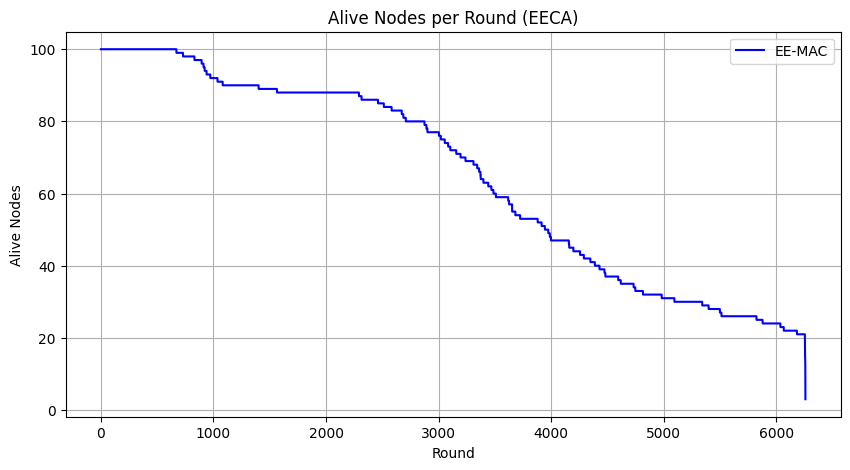

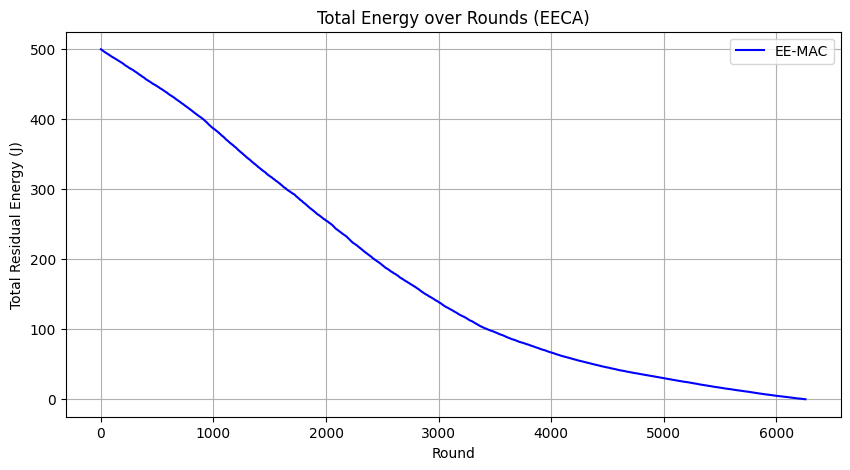

In [ ]:
# ==============================
# Run simulation
# ==============================
alive_eemac, energy_eemac, death_eemac = run_eeca()

# Only consider nodes that actually died
death_round_values = [r for r in death_eemac.values() if r is not None]
FND_eemac = min(death_round_values)
LND_eemac = max(death_round_values)

print("EE-MAC: FND =", FND_eemac, "LND =", LND_eemac)

# ==============================
# Plot
# ==============================
plt.figure(figsize=(10,5))
plt.plot(range(1,len(alive_eemac)+1), alive_eemac, color='blue', label='EE-MAC')
plt.xlabel("Round")
plt.ylabel("Alive Nodes")
plt.title("Alive Nodes per Round (EECA)")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(10,5))
plt.plot(range(1,len(energy_eemac)+1), energy_eemac, color='blue', label='EE-MAC')
plt.xlabel("Round")
plt.ylabel("Total Residual Energy (J)")
plt.title("Total Energy over Rounds (EECA)")
plt.grid(True)
plt.legend()
plt.show()
